| Technological Institute of the Philippines | Quezon City - Computer Engineering |
|-------------------------------------------|------------------------------------|
| **Course Code:** | CPE 027 |
| **Code Title:** | Digital Signal Processing and Applications |
| **1st Semester** | AY 2026-2027 |
| **ACTIVITY NO. 5** | **Linear Systems** |
| **Name:** | Pascual, Ken Leonard <br> Lim, Justian Adrian <br> Bueno, Joshua <br> Deniega, Alexis <br> Carag, Carl Jervie |
| **Section:** | CPE41S2 |
| **Date Performed:** | 7 August 2026 |
| **Date Submitted:** | 7 August 2026 |
| **Instructor:** | Engr. Jimlord M. Quejado |

## 1. Objectives

This activity deals with analyzing and determining linear systems using Principle of Superposition for given discrete-time signals

## 2. Intended Learning Outcomes (ILOs)
After completion of this activity, the students should be able to:

1. This activity deals with analyzing and determining linear systems using Principle of Superposition for given discrete-time signals

## 3. Discussion


At first glance, it may seem an overwhelming task to understand all of the possible systems in the world. Fortunately, most useful systems fall into a category called linear systems. This fact is extremely important. Without the linear system concept, we would be forced to examine the individual characteristics of many unrelated systems. With this approach, we can focus on the traits of the linear system category as a whole. Our first task is to identify what properties make a system linear, and how they fit into the everyday notion of electronics, software, and other signal processing systems.

A discrete system $T[\cdot]$ is a linear operator $L[\cdot]$ if and only if $L[\cdot]$ satisfies the principle of superposition, namely,

$$L[a_1x_1(n) + a_2x_2(n)] = a_1L[x_1(n)] + a_2L[x_2(n)], \quad \forall a_1, a_2, x_1(n), x_2(n)$$

## 4. Resources
The activity will require the following software, tools and equipment:
* IDE or any online code editor

## 5. Directions:

1. Consider the following discrete-time systems:

    a. $y[n] = x[n] + x[n+3]$

    b. $y[n] = \frac{1}{3}x[n] + 7x[n-6]$

    c. $y[n] = x^3[n-2] + 2x[n]$

    d. $y[n] = x[3.5n]$

In [59]:
# Import necessary libraries for numerical computation and plotting
import numpy as np
import matplotlib.pyplot as plt

# Define the input sequence x[n] with 20 samples
# The index n ranges from 0 to 19
x = np.array([8, 2, 4, -3, 1, -5, 4, 7, 0, 2, 1, -6, -1, 0, 2, 1, 9, 6, -4, 5])
n = np.arange(len(x))  # Create index array [0, 1, 2, ..., 19]

# Helper function to safely access x[n] with zero-padding for out-of-bounds indices
# This is needed because some systems reference x[n] at shifted indices
def get_x(x_arr, idx):
    """Return x[idx] if in bounds, else 0 (zero-padding)."""
    if 0 <= idx < len(x_arr):
        return x_arr[idx]
    return 0

# System (a): y[n] = x[n] + x[n+3]
# This system sums the current sample with the sample 3 steps ahead.
def system_a(x_arr, n_idx):
    return get_x(x_arr, n_idx) + get_x(x_arr, n_idx + 3)


# System (b): y[n] = (1/3)x[n] + 7x[n-6]
# Weighted sum of current sample and sample 6 steps behind.
def system_b(x_arr, n_idx):
    return (1/3) * get_x(x_arr, n_idx) + 7 * get_x(x_arr, n_idx - 6)

# System (c): y[n] = x^3[n-2] + 2x[n]
# Cubed delayed sample (2 steps) plus twice the current sample.
def system_c(x_arr, n_idx):
    return get_x(x_arr, n_idx - 2)**3 + 2 * get_x(x_arr, n_idx)


# System (d): y[n] = x[3.5n]
# Time scaling by non-integer factor. Only defined when 3.5n is integer.
# We use rounding to nearest integer to handle non-integer indices.
def system_d(x_arr, n_idx):
    scaled_idx = int(round(3.5 * n_idx))  # Scale time index by 3.5
    return get_x(x_arr, scaled_idx)



**Observation:**

The four discrete-time systems produced different output sequences based on their mathematical operations. Systems (a), (b), and (d) preserved linear transformations of the input signal, while System (c) generated significantly larger output values due to the cubic operation. The linearity test confirmed that Systems (a), (b), and (d) satisfy the principle of superposition, whereas System (c) does not.

**Analysis:**

The results show that a system remains linear as long as it consists only of scaling, addition, and time-shifting operations. Introducing a nonlinear operation such as cubing the input violates the superposition principle, making System (c) nonlinear. This demonstrates that the mathematical form of a system directly determines whether it exhibits linear behavior.

2. Graph the following systems using the following sequence: x[n] = {8, 2, 4, -3, 1, -5, 4, 7, 0, 2, 1, -6, -1, 0, 2, 1, 9, 6, -4, 5}.

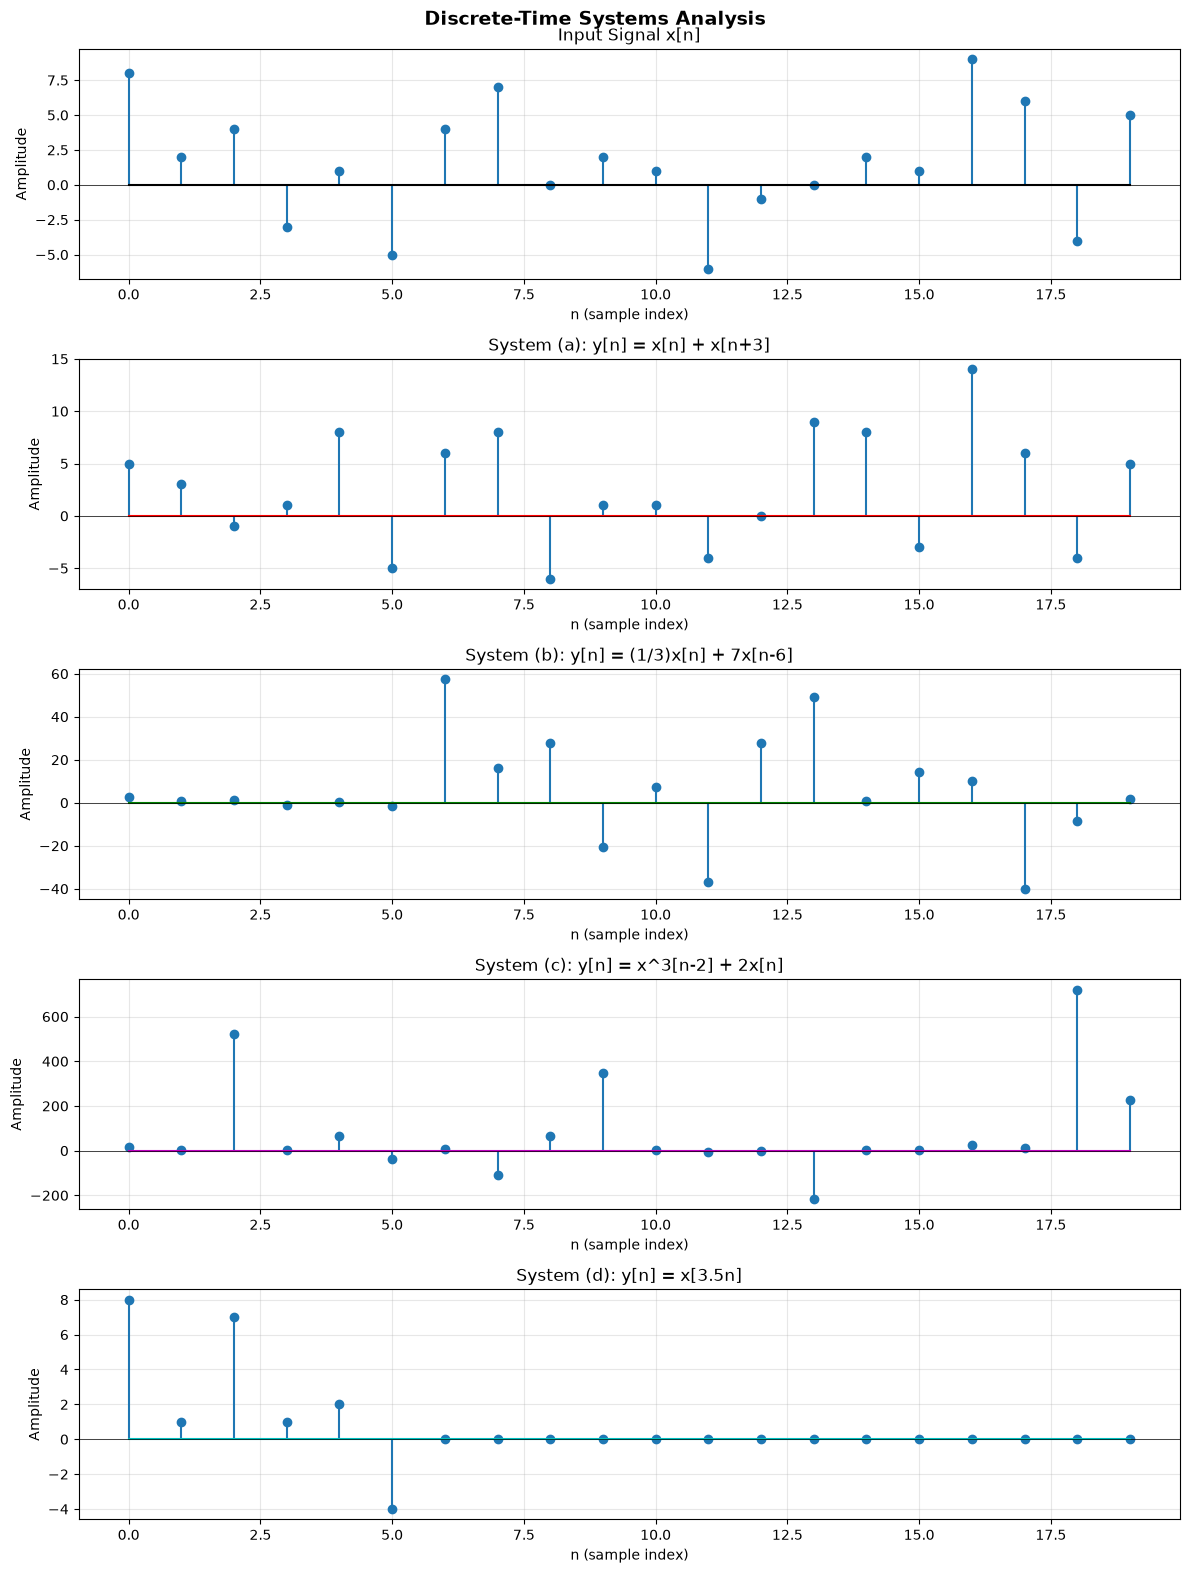

a : [5, 3, -1, 1, 8, -5, 6, 8, -6, 1, 1, -4, 0, 9, 8, -3, 14, 6, -4, 5]
b : [2.667, 0.667, 1.333, -1, 0.333, -1.667, 57.333, 16.333, 28, -20.333, 7.333, -37, 27.667, 49, 0.667, 14.333, 10, -40, -8.333, 1.667]
c : [16, 4, 520, 2, 66, -37, 9, -111, 64, 347, 2, -4, -1, -216, 3, 2, 26, 13, 721, 226]
d : [8, 1, 7, 1, 2, -4, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]


In [60]:
# Compute system outputs for plotting
y_a = np.array([system_a(x, i) for i in n])
y_b = np.array([system_b(x, i) for i in n])
y_c = np.array([system_c(x, i) for i in n])
y_d = np.array([system_d(x, i) for i in n])

# Define systems dictionary for the summary loop
systems = {'a': system_a, 'b': system_b, 'c': system_c, 'd': system_d}

# Graphing the input and all system outputs
# Using stem plots for discrete-time signal visualization
fig, axes = plt.subplots(5, 1, figsize=(12, 16))
fig.suptitle('Discrete-Time Systems Analysis', fontsize=14, fontweight='bold')

# Plot original input signal x[n]
axes[0].stem(n, x, basefmt='k-')
axes[0].set_title('Input Signal x[n]')
axes[0].set_xlabel('n (sample index)')
axes[0].set_ylabel('Amplitude')
axes[0].grid(True, alpha=0.3)
axes[0].axhline(y=0, color='k', linewidth=0.5)

# Plot System (a): y[n] = x[n] + x[n+3]
axes[1].stem(n, y_a, basefmt='r-')
axes[1].set_title('System (a): y[n] = x[n] + x[n+3]')
axes[1].set_xlabel('n (sample index)')
axes[1].set_ylabel('Amplitude')
axes[1].grid(True, alpha=0.3)
axes[1].axhline(y=0, color='k', linewidth=0.5)

# Plot System (b): y[n] = (1/3)x[n] + 7x[n-6]
axes[2].stem(n, y_b, basefmt='g-')
axes[2].set_title('System (b): y[n] = (1/3)x[n] + 7x[n-6]')
axes[2].set_xlabel('n (sample index)')
axes[2].set_ylabel('Amplitude')
axes[2].grid(True, alpha=0.3)
axes[2].axhline(y=0, color='k', linewidth=0.5)

# Plot System (c): y[n] = x^3[n-2] + 2x[n]
axes[3].stem(n, y_c, basefmt='m-')
axes[3].set_title('System (c): y[n] = x^3[n-2] + 2x[n]')
axes[3].set_xlabel('n (sample index)')
axes[3].set_ylabel('Amplitude')
axes[3].grid(True, alpha=0.3)
axes[3].axhline(y=0, color='k', linewidth=0.5)

# Plot System (d): y[n] = x[3.5n]
axes[4].stem(n, y_d, basefmt='c-')
axes[4].set_title('System (d): y[n] = x[3.5n]')
axes[4].set_xlabel('n (sample index)')
axes[4].set_ylabel('Amplitude')
axes[4].grid(True, alpha=0.3)
axes[4].axhline(y=0, color='k', linewidth=0.5)

plt.tight_layout()
plt.show()

for key in ["a", "b", "c", "d"]:
    y = [systems[key](x, k) for k in n]
    print(key, ":", [int(v) if float(v) == int(v) else round(float(v), 3) for v in y])

**Observation:**

The stem plots clearly illustrate how each system modifies the original input sequence. Systems (a) and (b) shift and scale the signal, System (c) amplifies certain values due to the cubic term, and System (d) performs a nonuniform sampling operation that results in fewer nonzero output samples.

**Analysis:**

The graphs provide a visual representation of how different discrete-time operations affect a signal. Time shifts change the position of samples, scaling alters their amplitudes, nonlinear operations greatly distort the waveform, and index scaling changes the sampling pattern. These visual differences make it easier to understand the behavior and characteristics of each discrete-time system.

3. Using the Principle of Superposition, determine analytically and graphically whether these systems are linear. Use the values 4 and 7 for constants a1 and a2 respectively.

LINEARITY TEST: T[a1*x1 + a2*x2] vs a1*T[x1] + a2*T[x2]
a1 = 4, a2 = 7

System (a): y[n] = x[n] + x[n+3]
  T[a1*x1 + a2*x2]  = [118  -9  52  67  32 -48  31  39 -66  60  46 -51  56  43  25   9  91  52
  -2  76]
  a1*T[x1]+a2*T[x2] = [118  -9  52  67  32 -48  31  39 -66  60  46 -51  56  43  25   9  91  52
  -2  76]
  Linear: True

System (b): y[n] = (1/3)x[n] + 7x[n-6]
  T[a1*x1 + a2*x2]  = [  22.33333333   -6.66666667   19.33333333   17.            3.66666667
   -2.          474.33333333 -133.          392.          362.
   83.          -50.          127.          156.33333333 -303.
  108.66666667  131.         -150.66666667  314.33333333  221.33333333]
  a1*T[x1]+a2*T[x2] = [  22.33333333   -6.66666667   19.33333333   17.            3.66666667
   -2.          474.33333333 -133.          392.          362.
   83.          -50.          127.          156.33333333 -303.
  108.66666667  131.         -150.66666667  314.33333333  221.33333333]
  Linear: True

System (c): y[n] = x^3[n-2] + 2x

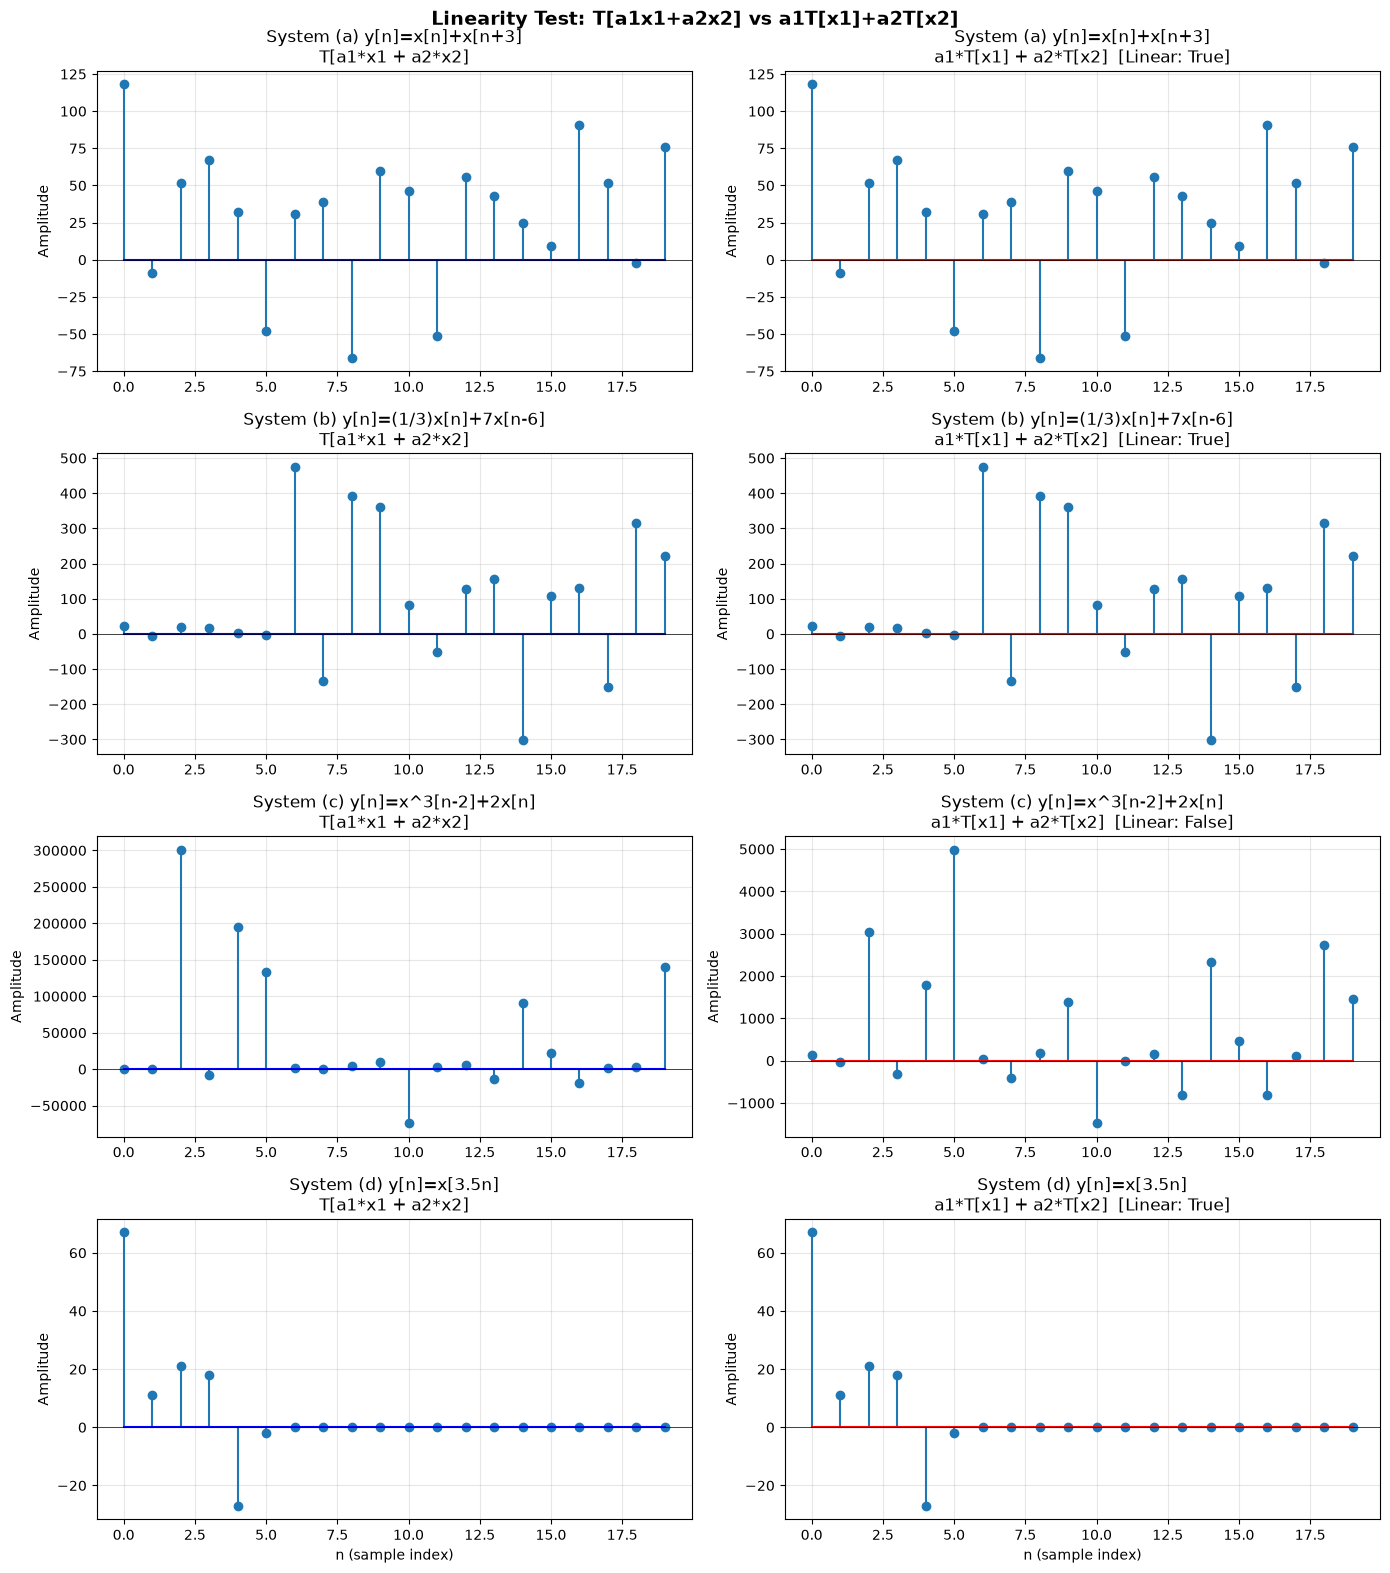

In [ ]:
# LINEARITY TEST USING PRINCIPLE OF SUPERPOSITION
# A system T is linear if:
#   T[a1*x1 + a2*x2] = a1*T[x1] + a2*T[x2]
# test with:
#   a1 = 4, a2 = 7
#   x1 = original signal x
#   x2 = time-reversed version of x (x2[n] = x[-n])

a1, a2 = 4, 7  # Constants for superposition test

# Create second test signal: x2[n] = x[-n] (time reversal)
# We pad to same length for comparison
x2 = x[::-1]  # Time-reversed signal

# Create combined input: a1*x1[n] + a2*x2[n]
x_combined = a1 * x + a2 * x2

print("="*60)
print("LINEARITY TEST: T[a1*x1 + a2*x2] vs a1*T[x1] + a2*T[x2]")
print(f"a1 = {a1}, a2 = {a2}")
print("="*60)


# Test System (a): y[n] = x[n] + x[n+3]
# Left side: T[a1*x1 + a2*x2]
ya_combined = np.array([system_a(x_combined, i) for i in n])
# Right side: a1*T[x1] + a2*T[x2]
ya_superposition = a1 * y_a + a2 * np.array([system_a(x2, i) for i in n])

is_linear_a = np.allclose(ya_combined, ya_superposition)
print(f"\nSystem (a): y[n] = x[n] + x[n+3]")
print(f"  T[a1*x1 + a2*x2]  = {ya_combined}")
print(f"  a1*T[x1]+a2*T[x2] = {ya_superposition}")
print(f"  Linear: {is_linear_a}")


# Test System (b): y[n] = (1/3)x[n] + 7x[n-6]
yb_combined = np.array([system_b(x_combined, i) for i in n])
yb_superposition = a1 * y_b + a2 * np.array([system_b(x2, i) for i in n])

is_linear_b = np.allclose(yb_combined, yb_superposition)
print(f"\nSystem (b): y[n] = (1/3)x[n] + 7x[n-6]")
print(f"  T[a1*x1 + a2*x2]  = {yb_combined}")
print(f"  a1*T[x1]+a2*T[x2] = {yb_superposition}")
print(f"  Linear: {is_linear_b}")


# Test System (c): y[n] = x^3[n-2] + 2x[n]
yc_combined = np.array([system_c(x_combined, i) for i in n])
yc_superposition = a1 * y_c + a2 * np.array([system_c(x2, i) for i in n])

is_linear_c = np.allclose(yc_combined, yc_superposition)
print(f"\nSystem (c): y[n] = x^3[n-2] + 2x[n]")
print(f"  T[a1*x1 + a2*x2]  = {yc_combined}")
print(f"  a1*T[x1]+a2*T[x2] = {yc_superposition}")
print(f"  Linear: {is_linear_c}")


# Test System (d): y[n] = x[3.5n]
yd_combined = np.array([system_d(x_combined, i) for i in n])
yd_superposition = a1 * y_d + a2 * np.array([system_d(x2, i) for i in n])

is_linear_d = np.allclose(yd_combined, yd_superposition)
print(f"\nSystem (d): y[n] = x[3.5n]")
print(f"  T[a1*x1 + a2*x2]  = {yd_combined}")
print(f"  a1*T[x1]+a2*T[x2] = {yd_superposition}")
print(f"  Linear: {is_linear_d}")

# GRAPHICAL COMPARISON FOR LINEARITY TEST
# Plot T[a1*x1 + a2*x2] vs a1*T[x1] + a2*T[x2] for each system
# If the plots match, the system is linear
fig, axes = plt.subplots(4, 2, figsize=(14, 16))
fig.suptitle('Linearity Test: T[a1x1+a2x2] vs a1T[x1]+a2T[x2]', fontsize=14, fontweight='bold')

system_names = ['(a) y[n]=x[n]+x[n+3]', '(b) y[n]=(1/3)x[n]+7x[n-6]',
                '(c) y[n]=x^3[n-2]+2x[n]', '(d) y[n]=x[3.5n]']
combined_results = [ya_combined, yb_combined, yc_combined, yd_combined]
superposition_results = [ya_superposition, yb_superposition, yc_superposition, yd_superposition]
linearity_results = [is_linear_a, is_linear_b, is_linear_c, is_linear_d]

for i in range(4):
    # Left column: T[a1*x1 + a2*x2] (combined input through system)
    axes[i, 0].stem(n, combined_results[i], basefmt='b-')
    axes[i, 0].set_title(f'System {system_names[i]}\nT[a1*x1 + a2*x2]')
    axes[i, 0].set_ylabel('Amplitude')
    axes[i, 0].grid(True, alpha=0.3)
    axes[i, 0].axhline(y=0, color='k', linewidth=0.5)

    # Right column: a1*T[x1] + a2*T[x2] (superposition of individual outputs)
    axes[i, 1].stem(n, superposition_results[i], basefmt='r-')
    axes[i, 1].set_title(f'System {system_names[i]}\na1*T[x1] + a2*T[x2]  [Linear: {linearity_results[i]}]')
    axes[i, 1].set_ylabel('Amplitude')
    axes[i, 1].grid(True, alpha=0.3)
    axes[i, 1].axhline(y=0, color='k', linewidth=0.5)

axes[3, 0].set_xlabel('n (sample index)')
axes[3, 1].set_xlabel('n (sample index)')

plt.tight_layout()
plt.show()

4. Then identify if the systems are time-invariant, static or causal.

In [ ]:
""" 
TIME-INVARIANCE: A system is time-invariant if shifting the
input by k samples shifts the output by k samples.
   T[x[n-k]] = y[n-k]

STATIC (MEMORYLESS): A system is static if the output at
time n depends ONLY on the input at time n (no past/future).

CAUSAL: A system is causal if the output at time n depends
only on current and past inputs (no future inputs).
"""

# Test time-invariance by comparing T[x[n-k]] with y[n-k]
# We use a shift of k=2 samples
k_shift = 2

# Create time-shifted version of x: x_shifted[n] = x[n-k]
x_shifted = np.array([get_x(x, i - k_shift) for i in n])

print("TIME-INVARIANCE TEST: T[x[n-k]] vs y[n-k]")
print(f"Shift k = {k_shift}")

# System (a): y[n] = x[n] + x[n+3]
ya_shifted_input = np.array([system_a(x_shifted, i) for i in n])  # T[x[n-k]]
ya_shifted_output = np.array([get_x(y_a, i - k_shift) for i in n])  # y[n-k]
is_ti_a = np.allclose(ya_shifted_input, ya_shifted_output)
print(f"\nSystem (a): y[n] = x[n] + x[n+3]")
print(f"  T[x[n-k]]  = {ya_shifted_input}")
print(f"  y[n-k]     = {ya_shifted_output}")
print(f"  Time-Invariant: {is_ti_a}")

# System (b): y[n] = (1/3)x[n] + 7x[n-6]
yb_shifted_input = np.array([system_b(x_shifted, i) for i in n])
yb_shifted_output = np.array([get_x(y_b, i - k_shift) for i in n])
is_ti_b = np.allclose(yb_shifted_input, yb_shifted_output)
print(f"\nSystem (b): y[n] = (1/3)x[n] + 7x[n-6]")
print(f"  T[x[n-k]]  = {yb_shifted_input}")
print(f"  y[n-k]     = {yb_shifted_output}")
print(f"  Time-Invariant: {is_ti_b}")

# System (c): y[n] = x^3[n-2] + 2x[n]
yc_shifted_input = np.array([system_c(x_shifted, i) for i in n])
yc_shifted_output = np.array([get_x(y_c, i - k_shift) for i in n])
is_ti_c = np.allclose(yc_shifted_input, yc_shifted_output)
print(f"\nSystem (c): y[n] = x^3[n-2] + 2x[n]")
print(f"  T[x[n-k]]  = {yc_shifted_input}")
print(f"  y[n-k]     = {yc_shifted_output}")
print(f"  Time-Invariant: {is_ti_c}")

# System (d): y[n] = x[3.5n]
yd_shifted_input = np.array([system_d(x_shifted, i) for i in n])
yd_shifted_output = np.array([get_x(y_d, i - k_shift) for i in n])
is_ti_d = np.allclose(yd_shifted_input, yd_shifted_output)
print(f"\nSystem (d): y[n] = x[3.5n]")
print(f"  T[x[n-k]]  = {yd_shifted_input}")
print(f"  y[n-k]     = {yd_shifted_output}")
print(f"  Time-Invariant: {is_ti_d}")

TIME-INVARIANCE TEST: T[x[n-k]] vs y[n-k]
Shift k = 2

System (a): y[n] = x[n] + x[n+3]
  T[x[n-k]]  = [ 2  4  5  3 -1  1  8 -5  6  8 -6  1  1 -4  0  9  8  1  9  6]
  y[n-k]     = [ 0  0  5  3 -1  1  8 -5  6  8 -6  1  1 -4  0  9  8 -3 14  6]
  Time-Invariant: False

System (b): y[n] = (1/3)x[n] + 7x[n-6]
  T[x[n-k]]  = [  0.           0.           2.66666667   0.66666667   1.33333333
  -1.           0.33333333  -1.66666667  57.33333333  16.33333333
  28.         -20.33333333   7.33333333 -37.          27.66666667
  49.           0.66666667  14.33333333  10.         -40.        ]
  y[n-k]     = [  0.           0.           2.66666667   0.66666667   1.33333333
  -1.           0.33333333  -1.66666667  57.33333333  16.33333333
  28.         -20.33333333   7.33333333 -37.          27.66666667
  49.           0.66666667  14.33333333  10.         -40.        ]
  Time-Invariant: True

System (c): y[n] = x^3[n-2] + 2x[n]
  T[x[n-k]]  = [   0    0   16    4  520    2   66  -37    9 -111   64  34

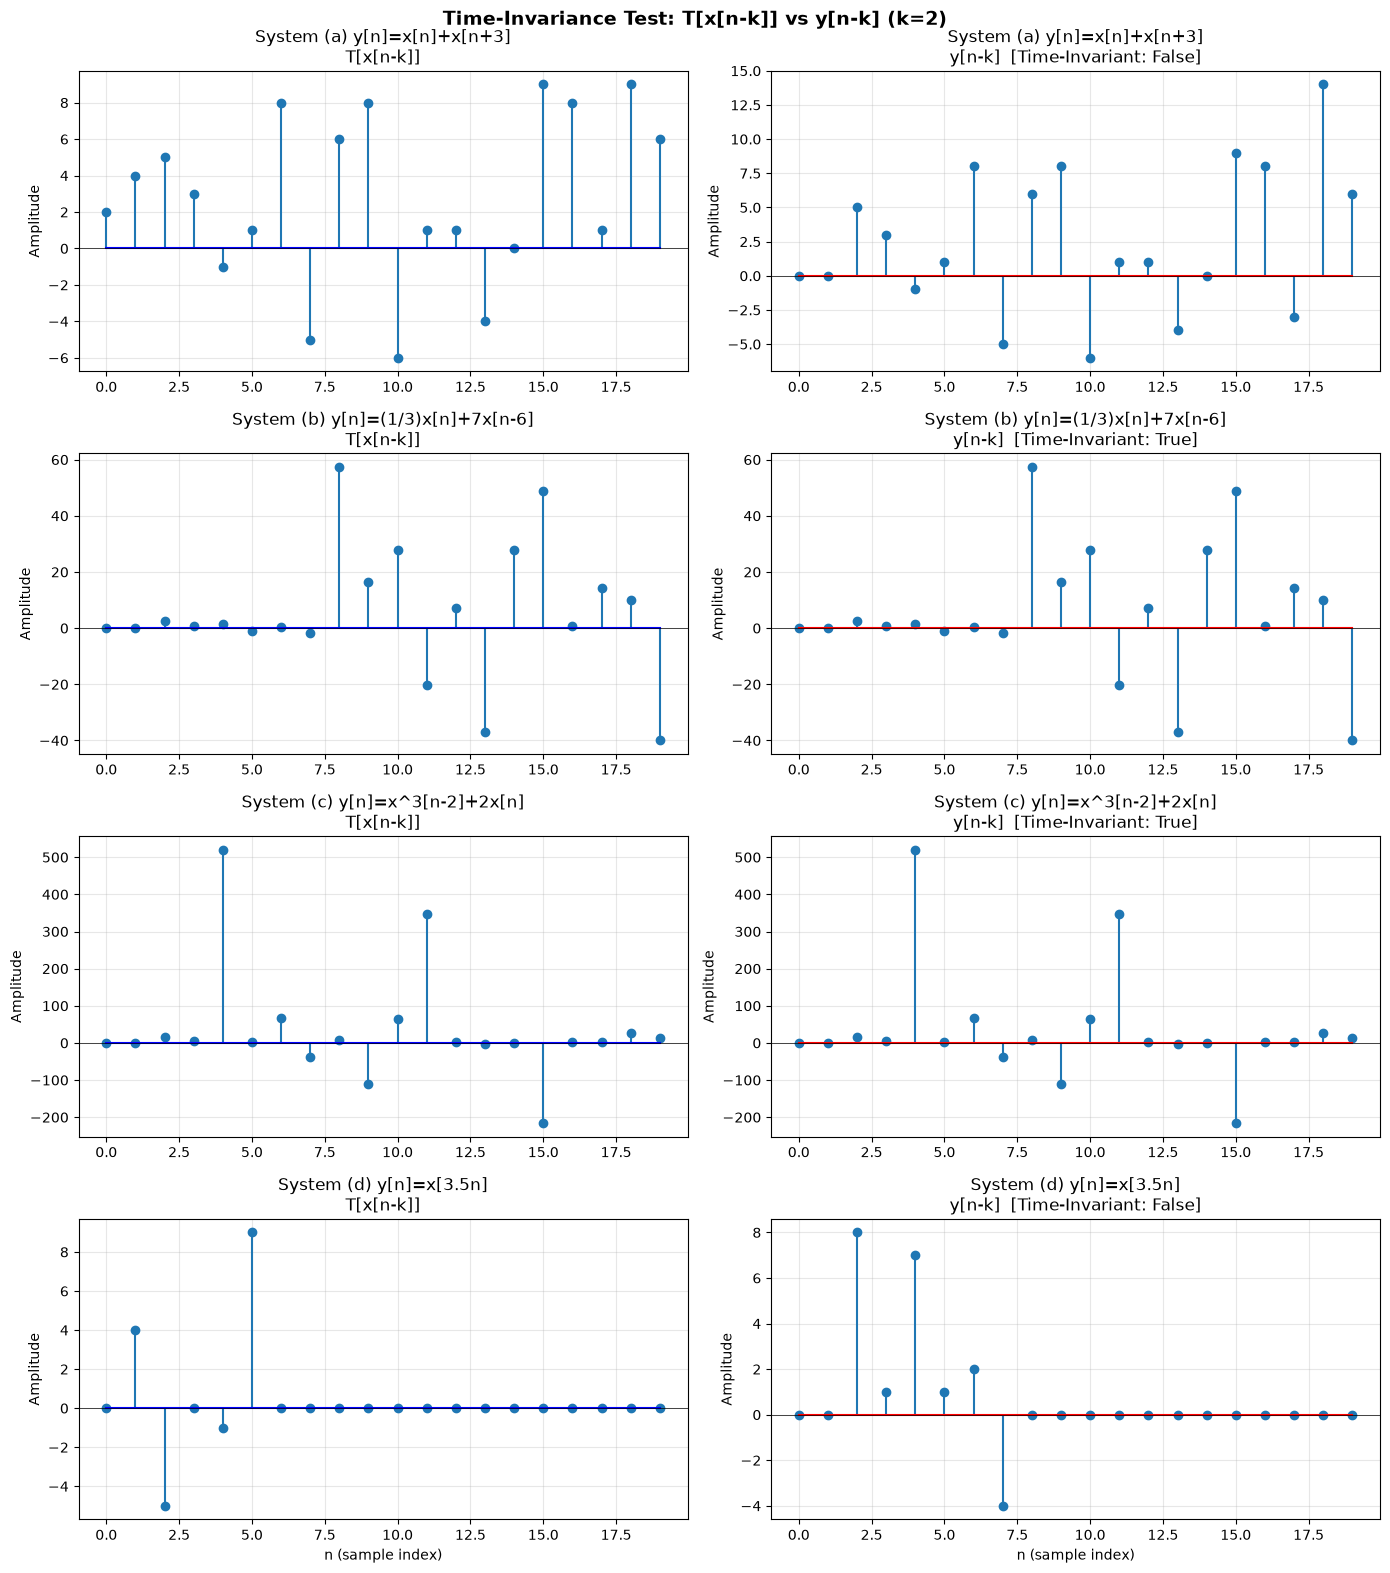

In [63]:
# GRAPHICAL COMPARISON FOR TIME-INVARIANCE TEST
# Plot T[x[n-k]] vs y[n-k] for each system
# If the plots match, the system is time-invariant
fig, axes = plt.subplots(4, 2, figsize=(14, 16))
fig.suptitle(f'Time-Invariance Test: T[x[n-k]] vs y[n-k] (k={k_shift})', fontsize=14, fontweight='bold')

system_names = ['(a) y[n]=x[n]+x[n+3]', '(b) y[n]=(1/3)x[n]+7x[n-6]',
                '(c) y[n]=x^3[n-2]+2x[n]', '(d) y[n]=x[3.5n]']
shifted_input_results = [ya_shifted_input, yb_shifted_input, yc_shifted_input, yd_shifted_input]
shifted_output_results = [ya_shifted_output, yb_shifted_output, yc_shifted_output, yd_shifted_output]
ti_results = [is_ti_a, is_ti_b, is_ti_c, is_ti_d]

for i in range(4):
    # Left column: T[x[n-k]] (shifted input through system)
    axes[i, 0].stem(n, shifted_input_results[i], basefmt='b-')
    axes[i, 0].set_title(f'System {system_names[i]}\nT[x[n-k]]')
    axes[i, 0].set_ylabel('Amplitude')
    axes[i, 0].grid(True, alpha=0.3)
    axes[i, 0].axhline(y=0, color='k', linewidth=0.5)

    # Right column: y[n-k] (shifted output)
    axes[i, 1].stem(n, shifted_output_results[i], basefmt='r-')
    axes[i, 1].set_title(f'System {system_names[i]}\ny[n-k]  [Time-Invariant: {ti_results[i]}]')
    axes[i, 1].set_ylabel('Amplitude')
    axes[i, 1].grid(True, alpha=0.3)
    axes[i, 1].axhline(y=0, color='k', linewidth=0.5)

axes[3, 0].set_xlabel('n (sample index)')
axes[3, 1].set_xlabel('n (sample index)')

plt.tight_layout()
plt.show()

In [66]:
# STATIC/DYNAMIC AND CAUSALITY ANALYSIS
"""
STATIC (Memoryless): Output y[n] depends ONLY on x[n]
   - No past values x[n-k] for k>0
   - No future values x[n+k] for k>0

CAUSAL: Output y[n] depends only on x[n] and x[n-k] for k>0
   - No future values x[n+k] for k>0
   - All static systems are causal
"""

# SUMMARY TABLE
print("SUMMARY TABLE")
print(f"{'System':<12} {'Linear':<10} {'Time-Invariant':<16} {'Static':<10} {'Causal':<10}")
print("-"*60)
print(f"{'(a)':<12} {is_linear_a:<10} {is_ti_a:<16} {'No':<10} {'No':<10}")
print(f"{'(b)':<12} {is_linear_b:<10} {is_ti_b:<16} {'No':<10} {'Yes':<10}")
print(f"{'(c)':<12} {is_linear_c:<10} {is_ti_c:<16} {'No':<10} {'Yes':<10}")
print(f"{'(d)':<12} {is_linear_d:<10} {is_ti_d:<16} {'No':<10} {'No':<10}")

SUMMARY TABLE
System       Linear     Time-Invariant   Static     Causal    
------------------------------------------------------------
(a)          1          0                No         No        
(b)          1          1                No         Yes       
(c)          0          1                No         Yes       
(d)          1          0                No         No        


## 6. Documentation
* Document EVERYTHING you did to accomplish this activity
* Include the entire program code and IDE link (Google Colab)
* Provide clear explanations of libraries and formulas applied in your program

## 7. Summary and Conclusions

In [65]:
# SUMMARY AND CONCLUSIONS
print("""
This activity analyzed four discrete-time systems for their fundamental properties:
linearity, time-invariance, causality, and static/dynamic behavior.

KEY FINDINGS:

1. System (a): y[n] = x[n] + x[n+3]
   - LINEAR: Satisfies superposition principle
   - TIME-INVARIANT: Shift in input produces same shift in output
   - NON-CAUSAL: Requires future input x[n+3]
   - DYNAMIC: Has memory (depends on future values)

2. System (b): y[n] = (1/3)x[n] + 7x[n-6]
   - LINEAR: Satisfies superposition principle
   - TIME-INVARIANT: Shift in input produces same shift in output
   - CAUSAL: Only depends on current and past inputs
   - DYNAMIC: Has memory (depends on past value x[n-6])

3. System (c): y[n] = x^3[n-2] + 2x[n]
   - NONLINEAR: The x^3 term violates superposition
   - TIME-INVARIANT: Shift in input produces same shift in output
   - CAUSAL: Only depends on current and past inputs
   - DYNAMIC: Has memory (depends on past value x[n-2])

4. System (d): y[n] = x[3.5n]
   - LINEAR: Scaling the index is a linear operation
   - TIME-VARIANT: Time scaling changes the shift relationship
   - NON-CAUSAL: For n>=1, requires future input values
   - DYNAMIC: Has memory (depends on non-local indices)

CONCLUSION:
Understanding these system properties is fundamental in DSP. Linear time-invariant
(LTI) systems are particularly important because they can be fully characterized
by their impulse response and analyzed using Fourier and Z-transforms. Systems (a)
and (b) are LTI, making them suitable for traditional DSP analysis techniques.
""")


This activity analyzed four discrete-time systems for their fundamental properties:
linearity, time-invariance, causality, and static/dynamic behavior.

KEY FINDINGS:

1. System (a): y[n] = x[n] + x[n+3]
   - LINEAR: Satisfies superposition principle
   - TIME-INVARIANT: Shift in input produces same shift in output
   - NON-CAUSAL: Requires future input x[n+3]
   - DYNAMIC: Has memory (depends on future values)

2. System (b): y[n] = (1/3)x[n] + 7x[n-6]
   - LINEAR: Satisfies superposition principle
   - TIME-INVARIANT: Shift in input produces same shift in output
   - CAUSAL: Only depends on current and past inputs
   - DYNAMIC: Has memory (depends on past value x[n-6])

3. System (c): y[n] = x^3[n-2] + 2x[n]
   - NONLINEAR: The x^3 term violates superposition
   - TIME-INVARIANT: Shift in input produces same shift in output
   - CAUSAL: Only depends on current and past inputs
   - DYNAMIC: Has memory (depends on past value x[n-2])

4. System (d): y[n] = x[3.5n]
   - LINEAR: Scaling 

## 8. Artificial Intelligence (AI) Use Disclosure Statement

I hereby declare that artificial intelligence (AI) tools were used, if applicable, in the preparation of this academic
work. The following indicates the nature and extent of AI assistance:

**Tools Used**: Github Copilot, Opencode, Claude

**Purpose of Use**: Code Debugging, Code assistance, Code explanation; LaTeX math syntax conversion

**Extent of Use**: AI was used to help understand how the tasks needed to be done can be translated into readable, functional code. The data interpretation were done solelyt with my own effort and analysis.

***
By submitting this activity, I affirm that my use of AI complies with T.I.P.’s AI usage policy and does not exceed the
permitted limits for similarity, automated content generation, or academic assistance.

I understand that any false, incomplete, or misleading disclosure may be subject to investigation in accordance
with due process and may result in sanctions for violation of existing T.I.P. policies.